### Step 1 — Mount Drive and define paths

In [1]:
# Step 1: Mount Google Drive and define paths

from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "phase3_validation_vis"

OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_MANIFEST_PHASE3 = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"
BEST_CKPT_PATH = CKPT_DIR / "conditional_unet3d_flow_phase3_train2000_val500_best.pt"

print("BASE_DIR exists:", BASE_DIR.exists())
print("SPLIT_DIR exists:", SPLIT_DIR.exists())
print("CKPT_DIR exists:", CKPT_DIR.exists())
print("OUT_DIR exists:", OUT_DIR.exists())

print("Validation manifest exists:", VAL_MANIFEST_PHASE3.exists())
print("Best checkpoint exists:", BEST_CKPT_PATH.exists())

Mounted at /content/drive
BASE_DIR exists: True
SPLIT_DIR exists: True
CKPT_DIR exists: True
OUT_DIR exists: True
Validation manifest exists: True
Best checkpoint exists: True


### Step 2 — Imports

In [2]:
# Step 2: Imports

import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader

### Step 3 — Reuse dataset and model definitions

In [4]:
# Step 3: Reuse existing definitions
# Required before continuing:
# - CubePair3DDataset
# - ConditionalUNetFlow3D
# - euler_sample_flow_3d
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)



class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # xt, x0: (B,1,D,H,W)
        # t:      (B,1,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])  # (B,1,D,H,W)
        inp = torch.cat([xt, x0, t_map], dim=1)  # (B,3,D,H,W)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)  # predicted velocity


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    """
    x0: (B,1,D,H,W)
    """
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### Step 4 — Build validation dataset and loader

In [5]:
# Step 4: Build validation dataset and loader

DOSE_SCALE = 1000.0

val_dataset_3d = CubePair3DDataset(VAL_MANIFEST_PHASE3, dose_scale=DOSE_SCALE)
val_loader_3d = DataLoader(val_dataset_3d, batch_size=1, shuffle=False, num_workers=0)

print("Validation dataset length:", len(val_dataset_3d))
print("Number of validation batches:", len(val_loader_3d))

Validation dataset length: 500
Number of validation batches: 500


### Step 5 — Load the best phase-3 flow checkpoint

In [6]:
# Step 5: Load the best phase-3 flow checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

best_ckpt = torch.load(BEST_CKPT_PATH, map_location="cpu")

flow_model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
flow_model.load_state_dict(best_ckpt["model_state_dict"])
flow_model.eval()

print("Checkpoint keys:", best_ckpt.keys())
print("Model loaded successfully.")

Using device: cuda
Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_losses', 'val_losses', 'best_val_loss', 'config'])
Model loaded successfully.


### Step 6 — Helper function: generate one flow prediction

In [7]:
# Step 6: Helper function for single-sample flow prediction

@torch.no_grad()
def get_flow_prediction(model, dataset, idx, device, n_steps=30):
    """
    Get one flow prediction from the dataset using Euler sampling.

    Args:
        model: trained flow model
        dataset: validation dataset
        idx: sample index
        device: torch device
        n_steps: number of Euler steps

    Returns:
        ct_vol, gt_vol, pred_vol as NumPy arrays
    """
    x0, x1 = dataset[idx]

    x0_t = x0.unsqueeze(0).to(device)   # [1, 1, D, H, W]
    pred = euler_sample_flow_3d(model, x0_t, n_steps=n_steps).cpu().squeeze().numpy()

    ct_vol = x0.squeeze().numpy()
    gt_vol = x1.squeeze().numpy()

    return ct_vol, gt_vol, pred

### Step 7 — Scan a few validation samples

In [8]:
# Step 7: Scan a few validation samples

def find_best_dose_slice_index(volume):
    """
    Find the slice index with the largest total dose intensity.
    """
    slice_sums = volume.reshape(volume.shape[0], -1).sum(axis=1)
    return int(np.argmax(slice_sums))

candidate_indices = [0, 1, 2, 3, 4]

for idx in candidate_indices:
    ct_vol, gt_vol, pred_vol = get_flow_prediction(flow_model, val_dataset_3d, idx, device, n_steps=30)
    slice_idx = find_best_dose_slice_index(gt_vol)
    print(f"Sample {idx}: best dose slice = {slice_idx}, gt max = {gt_vol.max():.4f}")

Sample 0: best dose slice = 16, gt max = 3.8319
Sample 1: best dose slice = 16, gt max = 3.4440
Sample 2: best dose slice = 16, gt max = 2.2094
Sample 3: best dose slice = 16, gt max = 3.8393
Sample 4: best dose slice = 16, gt max = 2.4772


### Step 8 — Choose one representative sample

In [9]:
# Step 8: Choose one representative sample

sample_idx = 3

ct_vol, gt_vol, pred_vol = get_flow_prediction(flow_model, val_dataset_3d, sample_idx, device, n_steps=30)

slice_idx = find_best_dose_slice_index(gt_vol)

print("Selected sample index:", sample_idx)
print("Reference slice index:", slice_idx)
print("GT max:", gt_vol.max())

Selected sample index: 3
Reference slice index: 16
GT max: 3.8393378


### Step 9 — Save the 4-panel comparison figure

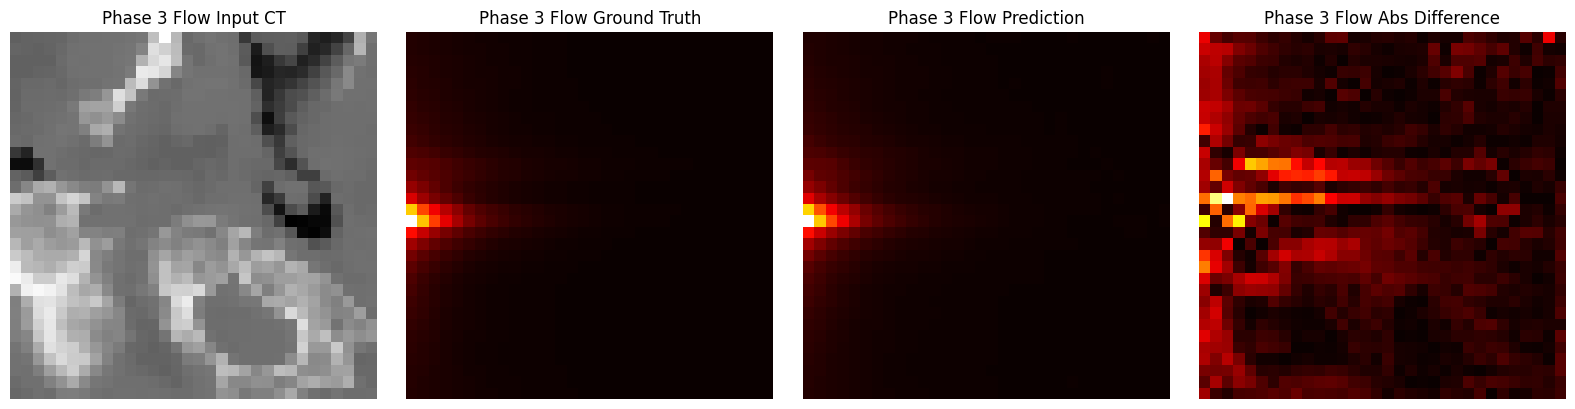

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_validation_vis/phase3_val_sample3_prediction_comparison.png


In [10]:
# Step 9: Save the 4-panel comparison figure

def save_prediction_comparison_figure(ct_vol, gt_vol, pred_vol, slice_idx, save_path, title_prefix=""):
    """
    Save a 4-panel comparison figure:
    - input CT
    - ground truth dose
    - predicted dose
    - absolute difference
    """
    diff_vol = np.abs(pred_vol - gt_vol)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(ct_vol[slice_idx], cmap="gray")
    axes[0].set_title(f"{title_prefix} Input CT")
    axes[0].axis("off")

    axes[1].imshow(gt_vol[slice_idx], cmap="hot")
    axes[1].set_title(f"{title_prefix} Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred_vol[slice_idx], cmap="hot")
    axes[2].set_title(f"{title_prefix} Prediction")
    axes[2].axis("off")

    axes[3].imshow(diff_vol[slice_idx], cmap="hot")
    axes[3].set_title(f"{title_prefix} Abs Difference")
    axes[3].axis("off")

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

save_prediction_comparison_figure(
    ct_vol,
    gt_vol,
    pred_vol,
    slice_idx,
    OUT_DIR / f"phase3_val_sample{sample_idx}_prediction_comparison.png",
    title_prefix="Phase 3 Flow"
)

### Step 10 — Find the beam-center reference point

In [11]:
# Step 10: Find the beam-center reference point

def find_peak_xy(volume, slice_idx):
    """
    Find the (y, x) location of the maximum value on a given slice.
    """
    slice_2d = volume[slice_idx]
    peak_idx = np.unravel_index(np.argmax(slice_2d), slice_2d.shape)
    return peak_idx  # (y, x)

peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

print("Reference beam center:")
print("peak_y =", peak_y)
print("peak_x =", peak_x)

Reference beam center:
peak_y = 16
peak_x = 0


### Step 11 — Plot along-beam profile

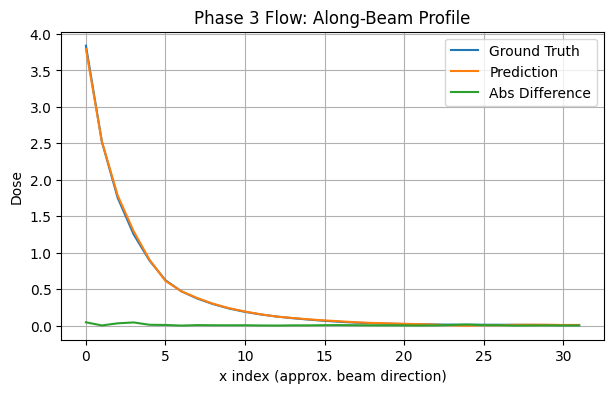

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_validation_vis/phase3_val_sample3_along_beam_profile.png


In [12]:
# Step 11: Plot along-beam profile

def plot_along_beam_profile(gt_vol, pred_vol, slice_idx, y_idx, save_path, title=""):
    """
    Plot the dose profile along the beam direction.
    """
    gt_profile = gt_vol[slice_idx, y_idx, :]
    pred_profile = pred_vol[slice_idx, y_idx, :]
    diff_profile = np.abs(pred_profile - gt_profile)

    x = np.arange(len(gt_profile))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x, gt_profile, label="Ground Truth")
    ax.plot(x, pred_profile, label="Prediction")
    ax.plot(x, diff_profile, label="Abs Difference")
    ax.set_title(title)
    ax.set_xlabel("x index (approx. beam direction)")
    ax.set_ylabel("Dose")
    ax.grid(True)
    ax.legend()

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

plot_along_beam_profile(
    gt_vol,
    pred_vol,
    slice_idx,
    peak_y,
    OUT_DIR / f"phase3_val_sample{sample_idx}_along_beam_profile.png",
    title="Phase 3 Flow: Along-Beam Profile"
)

### Step 12 — Plot perpendicular profile

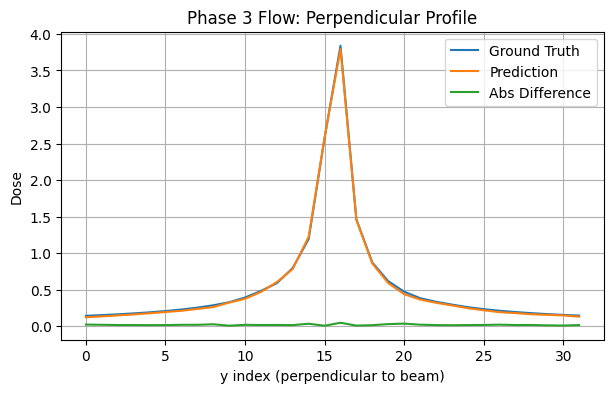

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_validation_vis/phase3_val_sample3_perpendicular_profile.png


In [13]:
# Step 12: Plot perpendicular profile

def plot_perpendicular_profile(gt_vol, pred_vol, slice_idx, x_idx, save_path, title=""):
    """
    Plot the dose profile perpendicular to the beam direction.
    """
    gt_profile = gt_vol[slice_idx, :, x_idx]
    pred_profile = pred_vol[slice_idx, :, x_idx]
    diff_profile = np.abs(pred_profile - gt_profile)

    y = np.arange(len(gt_profile))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(y, gt_profile, label="Ground Truth")
    ax.plot(y, pred_profile, label="Prediction")
    ax.plot(y, diff_profile, label="Abs Difference")
    ax.set_title(title)
    ax.set_xlabel("y index (perpendicular to beam)")
    ax.set_ylabel("Dose")
    ax.grid(True)
    ax.legend()

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

plot_perpendicular_profile(
    gt_vol,
    pred_vol,
    slice_idx,
    peak_x,
    OUT_DIR / f"phase3_val_sample{sample_idx}_perpendicular_profile.png",
    title="Phase 3 Flow: Perpendicular Profile"
)

### Step 13 — Optional reference-line overlay

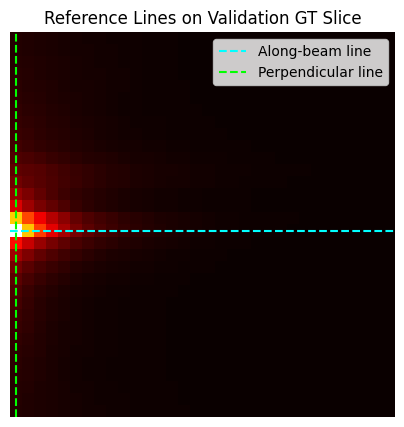

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_validation_vis/phase3_val_sample3_reference_lines.png


In [14]:
# Step 13: Optional reference-line overlay

def save_reference_line_figure(gt_vol, slice_idx, y_idx, x_idx, save_path, title=""):
    """
    Save the ground-truth slice with reference profile lines.
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(gt_vol[slice_idx], cmap="hot")
    ax.axhline(y=y_idx, color="cyan", linestyle="--", label="Along-beam line")
    ax.axvline(x=x_idx, color="lime", linestyle="--", label="Perpendicular line")
    ax.set_title(title)
    ax.axis("off")
    ax.legend()

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

save_reference_line_figure(
    gt_vol,
    slice_idx,
    peak_y,
    peak_x,
    OUT_DIR / f"phase3_val_sample{sample_idx}_reference_lines.png",
    title="Reference Lines on Validation GT Slice"
)

### Step 14 — Compute prediction metrics for the selected sample

In [15]:
# Step 14: Compute metrics for the selected sample

sample_mse = float(np.mean((pred_vol - gt_vol) ** 2))
sample_mae = float(np.mean(np.abs(pred_vol - gt_vol)))

print("Selected sample metrics:")
print("MSE =", sample_mse)
print("MAE =", sample_mae)

Selected sample metrics:
MSE = 4.086738408659585e-05
MAE = 0.004205371253192425
